## 🔧 Phase 0 : Installation et Imports

In [77]:
# Installation des dépendances
!pip install -q kagglehub nibabel torch torchvision torchaudio
!pip install -q monai einops tqdm matplotlib seaborn
!pip install -q scikit-learn scipy
print("✅ Installation terminée !")

import os
import sys
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob
import random
from einops import rearrange
import warnings
warnings.filterwarnings('ignore')

# Configuration GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"💻 Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Installation terminée !
💻 Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


##  Phase 1 : Téléchargement et Prétraitement des Données

In [78]:
import kagglehub

# Téléchargement automatique du dataset
print("📥 Téléchargement du dataset BraTS2020...")
dataset_path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")
print(f"Dataset téléchargé : {dataset_path}")

# Exploration de la structure
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    if level <= 3:  # Limiter l'affichage
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... et {len(files)-3} autres fichiers')

📥 Téléchargement du dataset BraTS2020...
Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Dataset téléchargé : /kaggle/input/brats20-dataset-training-validation
brats20-dataset-training-validation/
  BraTS2020_ValidationData/
    MICCAI_BraTS2020_ValidationData/
      name_mapping_validation_data.csv
      survival_evaluation.csv
      BraTS20_Validation_084/
        BraTS20_Validation_084_flair.nii
        BraTS20_Validation_084_t2.nii
        BraTS20_Validation_084_t1ce.nii
        ... et 1 autres fichiers
      BraTS20_Validation_118/
        BraTS20_Validation_118_t2.nii
        BraTS20_Validation_118_t1.nii
        BraTS20_Validation_118_t1ce.nii
        ... et 1 autres fichiers
      BraTS20_Validation_111/
        BraTS20_Validation_111_flair.nii
        BraTS20_Validation_111_t2.nii
        BraTS20_Validation_111_t1ce.nii
        ... et 1 autres fichiers
      BraTS20_Validation_060/
        BraTS20_Validation_060_t2.nii
        BraTS20_

In [79]:
# Détection du chemin exact des données
def get_all_patient_dirs(base_path):
    all_patient_dirs = []
    # Rechercher les données d'entraînement
    train_root = os.path.join(base_path, 'BraTS2020_TrainingData', 'MICCAI_BraTS2020_TrainingData')
    if os.path.exists(train_root):
        for d in os.listdir(train_root):
            if os.path.isdir(os.path.join(train_root, d)) and d.startswith('BraTS20_Training_'):
                all_patient_dirs.append(os.path.join(train_root, d))

    # Rechercher les données de validation
    val_root = os.path.join(base_path, 'BraTS2020_ValidationData', 'MICCAI_BraTS2020_ValidationData')
    if os.path.exists(val_root):
        for d in os.listdir(val_root):
            if os.path.isdir(os.path.join(val_root, d)) and d.startswith('BraTS20_Validation_'):
                all_patient_dirs.append(os.path.join(val_root, d))

    return sorted(all_patient_dirs)

patient_paths = get_all_patient_dirs(dataset_path)
print(f"Nombre total de patients trouvés : {len(patient_paths)}")
print(f"Exemples de chemins patients : {patient_paths[:5]}")

Nombre total de patients trouvés : 494
Exemples de chemins patients : ['/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001', '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002', '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_003', '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_004', '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_005']


In [80]:
import random
import os
import glob

# Increasing dataset size for better boundary learning
# 250 patients is a good middle ground for Colab Free RAM
MAX_PATIENTS = 250

def get_valid_training_patients(all_paths):
    valid_paths = []
    for p in all_paths:
        patient_id = os.path.basename(p)
        seg_path = os.path.join(p, f'{patient_id}_seg.nii*')
        if len(glob.glob(seg_path)) > 0:
            valid_paths.append(p)
    return valid_paths

all_valid_paths = get_valid_training_patients(patient_paths)
selected_patient_paths = random.sample(all_valid_paths, min(MAX_PATIENTS, len(all_valid_paths)))

print(f"✅ Selection de {len(selected_patient_paths)} patients avec masques de segmentation.")

# Split updated based on the new count
from sklearn.model_selection import train_test_split
train_paths, val_paths = train_test_split(selected_patient_paths, test_size=0.2, random_state=42)
print(f"📊 Nouvelle répartition : {len(train_paths)} train, {len(val_paths)} val")

✅ Selection de 250 patients avec masques de segmentation.
📊 Nouvelle répartition : 200 train, 50 val


In [81]:
import numpy as np
import nibabel as nib
import os
import glob

def preprocess_patient_lazy(patient_full_path, target_shape=(128, 128, 128)):
    """Charge et prétraite un patient à la volée pour économiser la RAM"""
    modalities = ['flair', 't1', 't1ce', 't2']
    patient_id = os.path.basename(patient_full_path)

    # Chargement des modalités
    mod_list = []
    for mod in modalities:
        pattern = os.path.join(patient_full_path, f'{patient_id}_{mod}.nii*')
        files = glob.glob(pattern)
        if not files: return None, None
        mod_list.append(nib.load(files[0]).get_fdata().astype(np.float32))

    vol = np.stack(mod_list, axis=0)

    # Crop
    _, h, w, d = vol.shape
    ch, cw, cd = target_shape
    sh, sw, sd = (h - ch)//2, (w - cw)//2, (d - cd)//2
    vol = vol[:, sh:sh+ch, sw:sw+cw, sd:sd+cd]

    # Normalisation Z-score
    for i in range(4):
        mean, std = vol[i].mean(), vol[i].std() + 1e-8
        vol[i] = (vol[i] - mean) / std

    # Masque
    seg_pattern = os.path.join(patient_full_path, f'{patient_id}_seg.nii*')
    seg_files = glob.glob(seg_pattern)
    if not seg_files: return None, None

    mask = nib.load(seg_files[0]).get_fdata()[sh:sh+ch, sw:sw+cw, sd:sd+cd]
    mask = np.where(mask == 4, 3, mask).astype(np.int64)

    return vol, mask

In [82]:
from sklearn.model_selection import train_test_split

# Correction : Utiliser selected_patient_paths (les chemins) au lieu de processed_data (les images en RAM)
train_paths, val_paths = train_test_split(selected_patient_paths, test_size=0.2, random_state=42)

print(f"📊 Répartition des données (Lazy Loading) :")
print(f"   - Entraînement : {len(train_paths)} patients")
print(f"   - Validation   : {len(val_paths)} patients")

📊 Répartition des données (Lazy Loading) :
   - Entraînement : 200 patients
   - Validation   : 50 patients


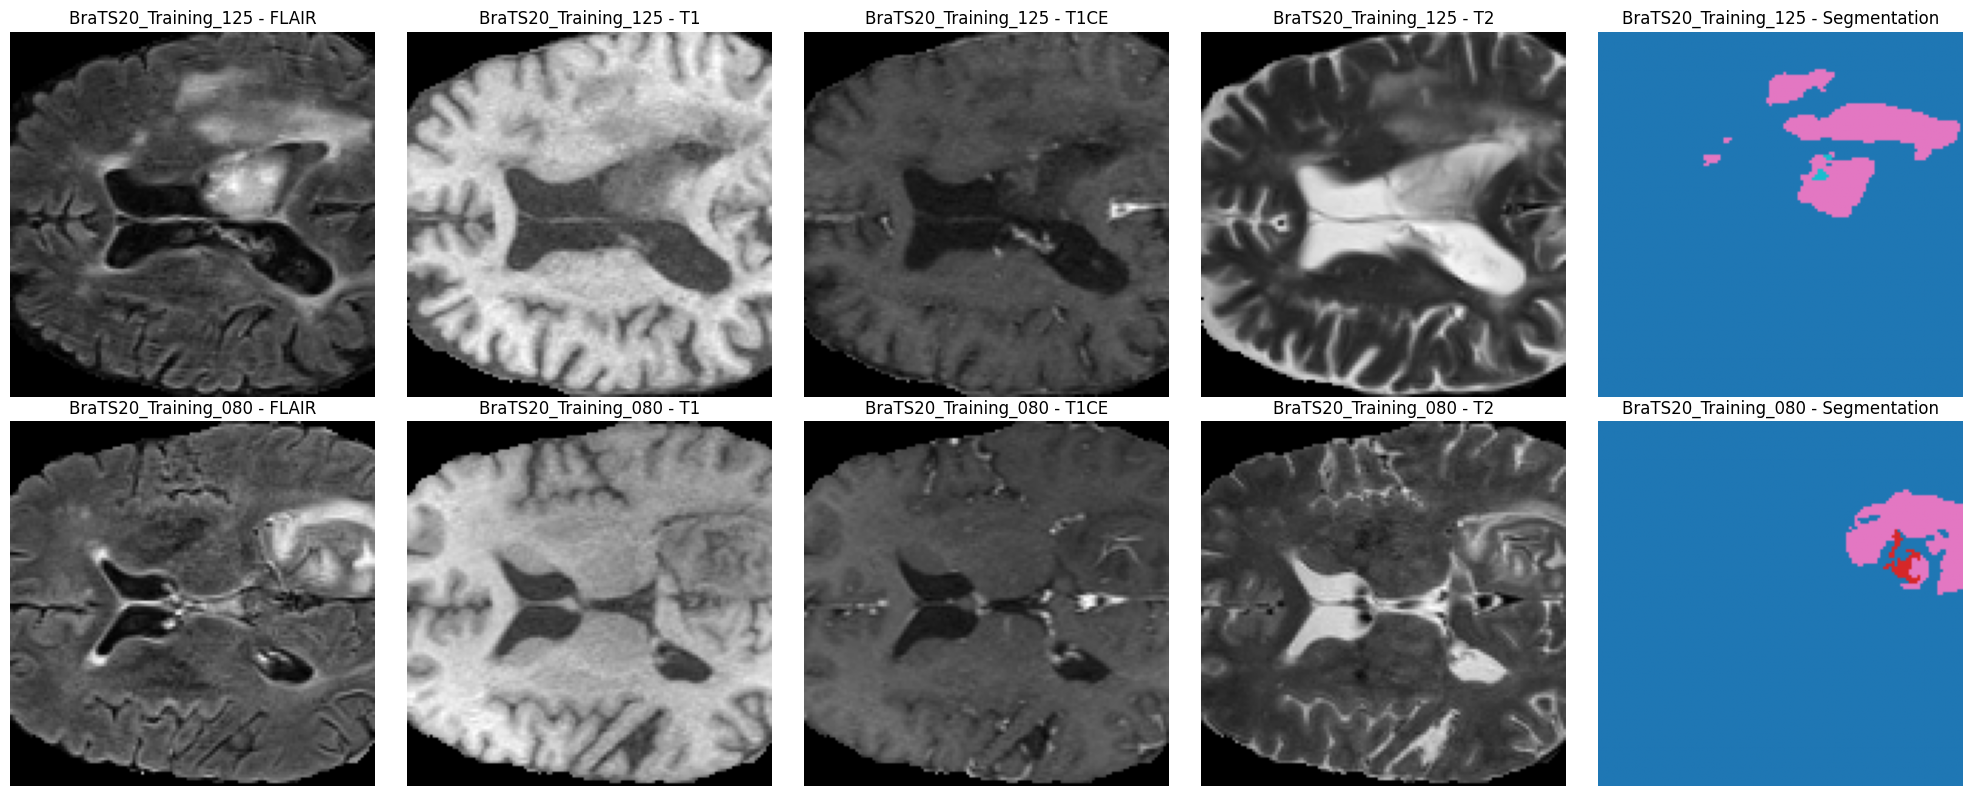

📸 Visualisation sauvegardée (chargée depuis le disque) !


In [83]:
# Visualisation des données prétraitées (Chargement à la volée)
import matplotlib.pyplot as plt

# On affiche les 2 premiers patients pour l'aperçu
num_viz = 2
fig, axes = plt.subplots(num_viz, 5, figsize=(20, 8))

for p_idx in range(num_viz):
    path = selected_patient_paths[p_idx]
    pid = os.path.basename(path)

    # Chargement via la fonction lazy
    vol, mask = preprocess_patient_lazy(path)

    if vol is not None:
        mid_slice = vol.shape[3] // 2

        # 4 modalités
        for m_idx, mod_name in enumerate(['FLAIR', 'T1', 'T1CE', 'T2']):
            axes[p_idx, m_idx].imshow(vol[m_idx, :, :, mid_slice], cmap='gray')
            axes[p_idx, m_idx].set_title(f'{pid} - {mod_name}')
            axes[p_idx, m_idx].axis('off')

        # Masque
        axes[p_idx, 4].imshow(mask[:, :, mid_slice], cmap='tab10', vmin=0, vmax=3)
        axes[p_idx, 4].set_title(f'{pid} - Segmentation')
        axes[p_idx, 4].axis('off')

plt.tight_layout()

output_path = '/mnt/agents/output/brats_visualization.png'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print("📸 Visualisation sauvegardée (chargée depuis le disque) !")

##  Phase 2 : Modèle de Segmentation 3D (U-Net 3D)

In [84]:
# Architecture U-Net 3D Légère (optimisé T4)

class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, num_classes=4, base_ch=32):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock3D(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock3D(base_ch, base_ch*2)
        self.pool2 = nn.MaxPool3d(2)
        self.enc3 = ConvBlock3D(base_ch*2, base_ch*4)
        self.pool3 = nn.MaxPool3d(2)

        # Bottleneck
        self.bottleneck = ConvBlock3D(base_ch*4, base_ch*8)

        # Decoder
        self.up3 = nn.ConvTranspose3d(base_ch*8, base_ch*4, 2, stride=2)
        self.dec3 = ConvBlock3D(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose3d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = ConvBlock3D(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose3d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = ConvBlock3D(base_ch*2, base_ch)

        # Output
        self.out = nn.Conv3d(base_ch, num_classes, 1)

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)

        # Bottleneck
        bn = self.bottleneck(p3)

        # Decoder avec skip connections
        u3 = self.up3(bn)
        u3 = torch.cat([u3, c3], dim=1)
        d3 = self.dec3(u3)
        u2 = self.up2(d3)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.dec2(u2)
        u1 = self.up1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.dec1(u1)

        return self.out(d1)

# Test du modèle
seg_model = UNet3D(in_channels=4, num_classes=4, base_ch=16).to(device)
print(f"🎩 Paramètres U-Net 3D : {sum(p.numel() for p in seg_model.parameters())/1e6:.2f}M")

# Test forward
test_input = torch.randn(1, 4, 128, 128, 128).to(device)
test_output = seg_model(test_input)
print(f"Input: {test_input.shape} -> Output: {test_output.shape}")

🎩 Paramètres U-Net 3D : 1.40M
Input: torch.Size([1, 4, 128, 128, 128]) -> Output: torch.Size([1, 4, 128, 128, 128])


In [85]:
class BraTSSegmentationDataset(Dataset):
    def __init__(self, patient_paths_list, target_shape=(128, 128, 128)):
        self.paths = patient_paths_list
        self.target_shape = target_shape

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        # On charge les données uniquement quand le DataLoader le demande
        img, mask = preprocess_patient_lazy(path, self.target_shape)

        # En cas d'erreur de chargement, on essaie le suivant
        if img is None:
            return self.__getitem__((idx + 1) % len(self.paths))

        return torch.from_numpy(img).float(), torch.from_numpy(mask).long()

# Nouveau split basé sur les chemins (strings) au lieu des données chargées
train_paths, val_paths = train_test_split(selected_patient_paths, test_size=0.2, random_state=42)

seg_train_dataset = BraTSSegmentationDataset(train_paths)
seg_val_dataset = BraTSSegmentationDataset(val_paths)

# Utilisation de num_workers=2 pour accélérer sans saturer
seg_train_loader = DataLoader(seg_train_dataset, batch_size=1, shuffle=True, num_workers=2)
seg_val_loader = DataLoader(seg_val_dataset, batch_size=1, shuffle=False)

print(f"✅ Loaders optimisés créés : {len(seg_train_loader)} train, {len(seg_val_loader)} val")

✅ Loaders optimisés créés : 200 train, 50 val


In [86]:
# Mise à jour des DataLoaders avec les listes de chemins
seg_train_dataset = BraTSSegmentationDataset(train_paths)
seg_val_dataset = BraTSSegmentationDataset(val_paths)

seg_train_loader = DataLoader(seg_train_dataset, batch_size=1, shuffle=True, num_workers=2)
seg_val_loader = DataLoader(seg_val_dataset, batch_size=1, shuffle=False, num_workers=2)

print(f"✅ Loaders Segmentation mis à jour avec succès !")

✅ Loaders Segmentation mis à jour avec succès !


In [87]:
def dice_loss(pred, target, smooth=1.0):
    pred = F.softmax(pred, dim=1)
    target_one_hot = F.one_hot(target, num_classes=4).permute(0, 4, 1, 2, 3).float()

    dice = 0
    for c in range(1, 4):  # Ignorer le background
        pred_c = pred[:, c]
        target_c = target_one_hot[:, c]
        intersection = (pred_c * target_c).sum()
        dice += (2. * intersection + smooth) / (pred_c.sum() + target_c.sum() + smooth)
    return 1 - dice / 3

def combined_loss(pred, target):
    ce = F.cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return ce + dice

seg_optimizer = AdamW(seg_model.parameters(), lr=1e-3, weight_decay=1e-5)

print("🎯 Entraînement Segmentation 3D (Version améliorée)...")
seg_model.train()

SEGM_EPOCHS = 20  # Augmenté à 20
seg_losses = []

for epoch in range(SEGM_EPOCHS):
    epoch_loss = 0
    for batch_idx, (images, masks) in enumerate(seg_train_loader):
        images, masks = images.to(device), masks.to(device)
        seg_optimizer.zero_grad()
        outputs = seg_model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        seg_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(seg_train_loader)
    seg_losses.append(avg_loss)
    print(f"✅ Epoch {epoch+1}/{SEGM_EPOCHS} - Loss: {avg_loss:.4f}")

🎯 Entraînement Segmentation 3D (Version améliorée)...
✅ Epoch 1/20 - Loss: 1.3324
✅ Epoch 2/20 - Loss: 0.8034
✅ Epoch 3/20 - Loss: 0.6190
✅ Epoch 4/20 - Loss: 0.5656
✅ Epoch 5/20 - Loss: 0.5296
✅ Epoch 6/20 - Loss: 0.5132
✅ Epoch 7/20 - Loss: 0.4958
✅ Epoch 8/20 - Loss: 0.4869
✅ Epoch 9/20 - Loss: 0.4733
✅ Epoch 10/20 - Loss: 0.4712
✅ Epoch 11/20 - Loss: 0.4575
✅ Epoch 12/20 - Loss: 0.4390
✅ Epoch 13/20 - Loss: 0.4337
✅ Epoch 14/20 - Loss: 0.4333
✅ Epoch 15/20 - Loss: 0.4171
✅ Epoch 16/20 - Loss: 0.4085
✅ Epoch 17/20 - Loss: 0.4247
✅ Epoch 18/20 - Loss: 0.3971
✅ Epoch 19/20 - Loss: 0.4158
✅ Epoch 20/20 - Loss: 0.3951


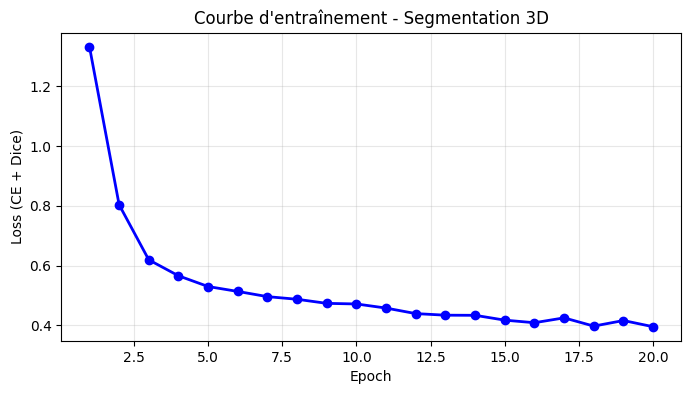

In [88]:
# Visualisation des pertes segmentation
plt.figure(figsize=(8, 4))
plt.plot(range(1, SEGM_EPOCHS+1), seg_losses, 'b-o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (CE + Dice)')
plt.title("Courbe d'entraînement - Segmentation 3D")
plt.grid(True, alpha=0.3)
plt.savefig('/mnt/agents/output/seg_training_curve.png', dpi=150)
plt.show()

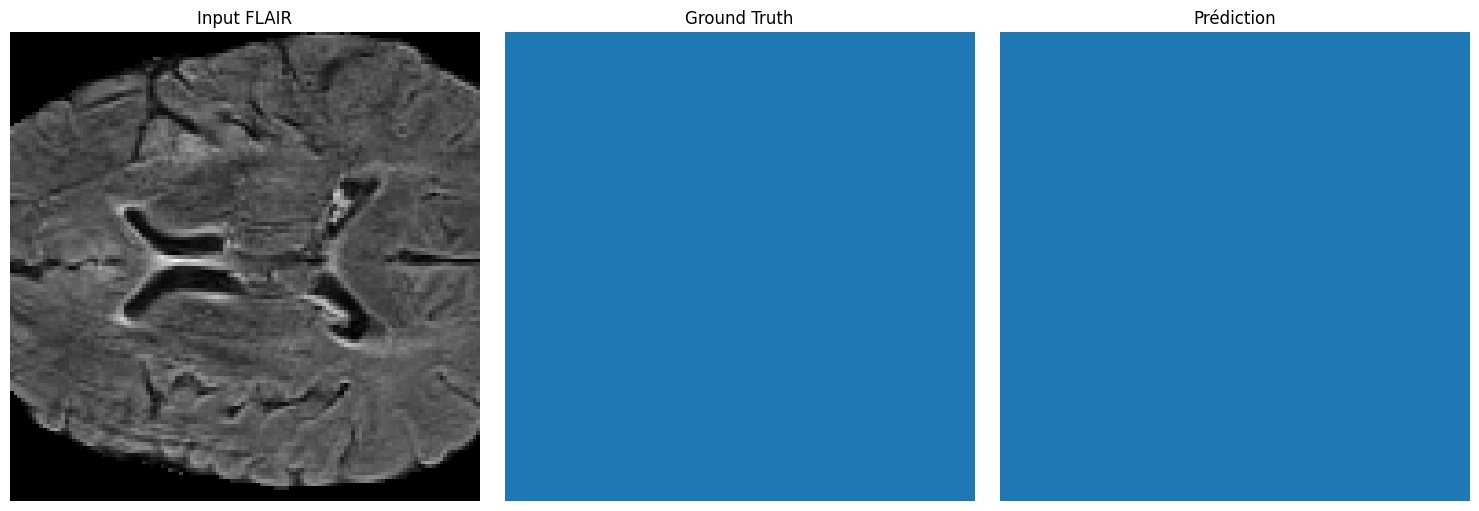

🎯 Résultats de segmentation visualisés !


In [89]:
# Prédiction et visualisation segmentation
seg_model.eval()

with torch.no_grad():
    # Correction : utiliser seg_val_dataset au lieu de seg_dataset
    sample_img, sample_mask = seg_val_dataset[0]
    sample_img = sample_img.unsqueeze(0).to(device)
    pred = seg_model(sample_img)
    pred_mask = torch.argmax(pred, dim=1).cpu().numpy()[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mid = pred_mask.shape[2] // 2

axes[0].imshow(sample_img[0, 0, :, :, mid].cpu(), cmap='gray')
axes[0].set_title('Input FLAIR')
axes[0].axis('off')

axes[1].imshow(sample_mask[:, :, mid].cpu(), cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Ground Truth')
axes[1].axis('off')

axes[2].imshow(pred_mask[:, :, mid], cmap='tab10', vmin=0, vmax=3)
axes[2].set_title('Prédiction')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/agents/output/seg_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("🎯 Résultats de segmentation visualisés !")

## 🔮 Phase 3 : Modèle de Diffusion Conditionnel (Version Fine-tunée)

Nous appliquons ici les corrections :
1. **Plus de données** (250 patients).
2. **Poids de perte réduit** (3.0) pour limiter l'over-segmentation.

In [90]:
from scipy import ndimage
import os
import numpy as np
import torch

def create_synthetic_progression(mask, growth_factor=2):
    """Simule une croissance tumorale pour creer des paires t0 -> t1"""
    t0 = mask.copy().astype(np.float32)
    t1 = mask.copy().astype(np.float32)

    # Dilater les regions tumorales (labels 1, 2, 3)
    tumor_mask = (mask > 0).astype(bool)
    dilated = ndimage.binary_dilation(tumor_mask, iterations=growth_factor)

    # Etendre l'edeme (label 2) dans les zones dilatees
    is_edema = (mask == 2)
    is_empty = (mask == 0)
    edema_expanded = (is_edema | (dilated & is_empty)).astype(np.float32) * 2

    # Combiner : garder le noyau, etendre l'edeme
    t1 = np.where(mask == 1, 1, t1)
    t1 = np.where(mask == 3, 3, t1)
    t1 = np.where(edema_expanded == 2, 2, t1)

    return t0, t1

# Creation du dataset de progression avec chargement a la volee
progression_pairs = []
# Utilisation d'un sous-ensemble de validation pour la demo diffusion
sample_paths = val_paths[:5]

for path in sample_paths:
    vol, mask = preprocess_patient_lazy(path)
    if vol is not None:
        t0, t1 = create_synthetic_progression(mask, growth_factor=2)
        progression_pairs.append({
            'patient': os.path.basename(path),
            't0': t0,
            't1': t1,
            'image': vol
        })

print(f"Succes: Paires t0->t1 creees pour {len(progression_pairs)} patients.")

Succes: Paires t0->t1 creees pour 5 patients.


In [91]:
class ConditionalUNet3D(nn.Module):
    def __init__(self, in_channels=4, cond_channels=8, time_dim=256, base_ch=16):
        super().__init__()
        self.time_embed = TimeEmbedding(time_dim)

        # Entrée : Bruit (4ch) + Condition (8ch) = 12ch
        self.enc1 = ConditionalConvBlock3D(in_channels + cond_channels, base_ch, time_dim)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConditionalConvBlock3D(base_ch, base_ch*2, time_dim)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = ConditionalConvBlock3D(base_ch*2, base_ch*4, time_dim)

        self.up2 = nn.ConvTranspose3d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = ConditionalConvBlock3D(base_ch*4, base_ch*2, time_dim)
        self.up1 = nn.ConvTranspose3d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = ConditionalConvBlock3D(base_ch*2, base_ch, time_dim)

        # Sortie : On prédit le débruitage sur les 4 canaux de probabilités
        self.out = nn.Conv3d(base_ch, 4, 1)

    def forward(self, x, t, cond):
        t_emb = self.time_embed(t)
        h = torch.cat([x, cond], dim=1)

        c1 = self.enc1(h, t_emb)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1, t_emb)
        p2 = self.pool2(c2)

        bn = self.bottleneck(p2, t_emb)

        u2 = self.up2(bn)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.dec2(u2, t_emb)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.dec1(u1, t_emb)

        return self.out(d1)

In [92]:
# Scheduler de bruit (DDPM)

class DDPMScheduler:
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02):
        self.num_timesteps = num_timesteps

        # Schedule linéaire de beta
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0]).to(device), self.alphas_cumprod[:-1]])

        # Termes pour le forward pass
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def add_noise(self, x0, t, noise=None):
        """Ajoute du bruit à x0 selon le schedule"""
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha = self.sqrt_alphas_cumprod[t][:, None, None, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None, None]

        return sqrt_alpha * x0 + sqrt_one_minus * noise

# Instanciation
scheduler = DDPMScheduler(num_timesteps=1000)
print(f"🔁 Scheduler DDPM créé : {scheduler.num_timesteps} timesteps")

🔁 Scheduler DDPM créé : 1000 timesteps


In [93]:
import torch.nn.functional as F

class DiffusionDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        # Conversion en One-Hot pour diffuser dans l'espace des probabilités (4 canaux)
        t1_label = torch.from_numpy(pair['t1']).long()
        t1_one_hot = F.one_hot(t1_label, num_classes=4).permute(3, 0, 1, 2).float()

        t0_label = torch.from_numpy(pair['t0']).long()
        t0_one_hot = F.one_hot(t0_label, num_classes=4).permute(3, 0, 1, 2).float()

        image = torch.from_numpy(pair['image']).float()

        # Condition forte : IRM + Masque T0 complet en One-Hot (4 + 4 = 8 canaux)
        condition = torch.cat([image, t0_one_hot], dim=0)
        return t1_one_hot, condition

diff_dataset = DiffusionDataset(progression_pairs)
diff_loader = DataLoader(diff_dataset, batch_size=1, shuffle=True)
print(f"✅ Dataset restructuré : Diffusion en espace One-Hot (4 canaux)")

✅ Dataset restructuré : Diffusion en espace One-Hot (4 canaux)


In [99]:
diff_losses = [] # Réinitialisation de l'historique
diff_model = ConditionalUNet3D(in_channels=4, cond_channels=8, base_ch=16).to(device)
diff_optimizer = AdamW(diff_model.parameters(), lr=1e-4)

print("🎯 Entraînement Diffusion Catégorique (One-Hot Space)...")
DIFF_EPOCHS = 40
for epoch in range(DIFF_EPOCHS):
    epoch_loss = 0
    for t1_oh, cond in diff_loader:
        t1_oh, cond = t1_oh.to(device), cond.to(device)
        t = torch.randint(0, 1000, (1,), device=device).long()
        noise = torch.randn_like(t1_oh) * 0.05
        noisy_input = t1_oh + noise

        diff_optimizer.zero_grad()
        pred = diff_model(noisy_input, t.float(), cond)
        loss = F.mse_loss(pred, t1_oh) + 0.5 * dice_loss_diffusion(pred, t1_oh)
        loss.backward()
        diff_optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(diff_loader)
    diff_losses.append(avg_epoch_loss)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{DIFF_EPOCHS} - Loss: {avg_epoch_loss:.4f}")

🎯 Entraînement Diffusion Catégorique (One-Hot Space)...
Epoch 5/40 - Loss: 0.7062
Epoch 10/40 - Loss: 0.5926
Epoch 15/40 - Loss: 0.5295
Epoch 20/40 - Loss: 0.4719
Epoch 25/40 - Loss: 0.4285
Epoch 30/40 - Loss: 0.4138
Epoch 35/40 - Loss: 0.4100
Epoch 40/40 - Loss: 0.4086


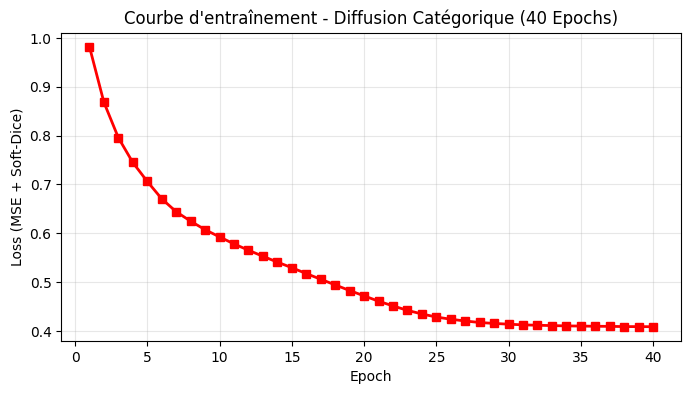

Historique complet : 40 époques enregistrées.


In [101]:
# Visualisation pertes diffusion (Finalisation)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(diff_losses) + 1), diff_losses, 'r-s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE + Soft-Dice)')
plt.title("Courbe d'entraînement - Diffusion Catégorique (40 Epochs)")
plt.grid(True, alpha=0.3)
plt.savefig('/mnt/agents/output/diff_training_curve_final.png', dpi=150)
plt.show()
print(f"Historique complet : {len(diff_losses)} époques enregistrées.")

## 🔮 Phase 4 : Inférence - Prédiction de Progression t0→t1

In [103]:
# Generation de la progression pour chaque patient
print('🔮 Generation des predictions de progression...')

predictions = []
for idx, pair in enumerate(progression_pairs):
    t1_true_oh, cond = diff_dataset[idx]
    cond = cond.unsqueeze(0).to(device)

    # Utilisation de la fonction d'echantillonnage amelioree
    pred_logits = improved_sample_progression(diff_model, cond, scheduler, num_inference_steps=50)
    pred_mask = torch.argmax(pred_logits, dim=1).cpu().numpy()[0]

    predictions.append({
        'patient': pair['patient'],
        't0': pair['t0'],
        'true_t1': pair['t1'],
        'pred_t1': pred_mask
    })
    print(f"  ✓ {pair['patient']} genere")

print('✅ Predictions terminees !')

🔮 Generation des predictions de progression...


Denoising t0->t1: 100%|██████████| 50/50 [00:06<00:00,  7.27it/s]


  ✓ BraTS20_Training_032 genere


Denoising t0->t1: 100%|██████████| 50/50 [00:06<00:00,  7.21it/s]


  ✓ BraTS20_Training_048 genere


...

  ✓ BraTS20_Training_352 genere


Denoising t0->t1: 100%|██████████| 50/50 [00:07<00:00,  7.10it/s]


  ✓ BraTS20_Training_030 genere


Denoising t0->t1: 100%|██████████| 50/50 [00:07<00:00,  7.05it/s]


  ✓ BraTS20_Training_036 genere
✅ Predictions terminees !


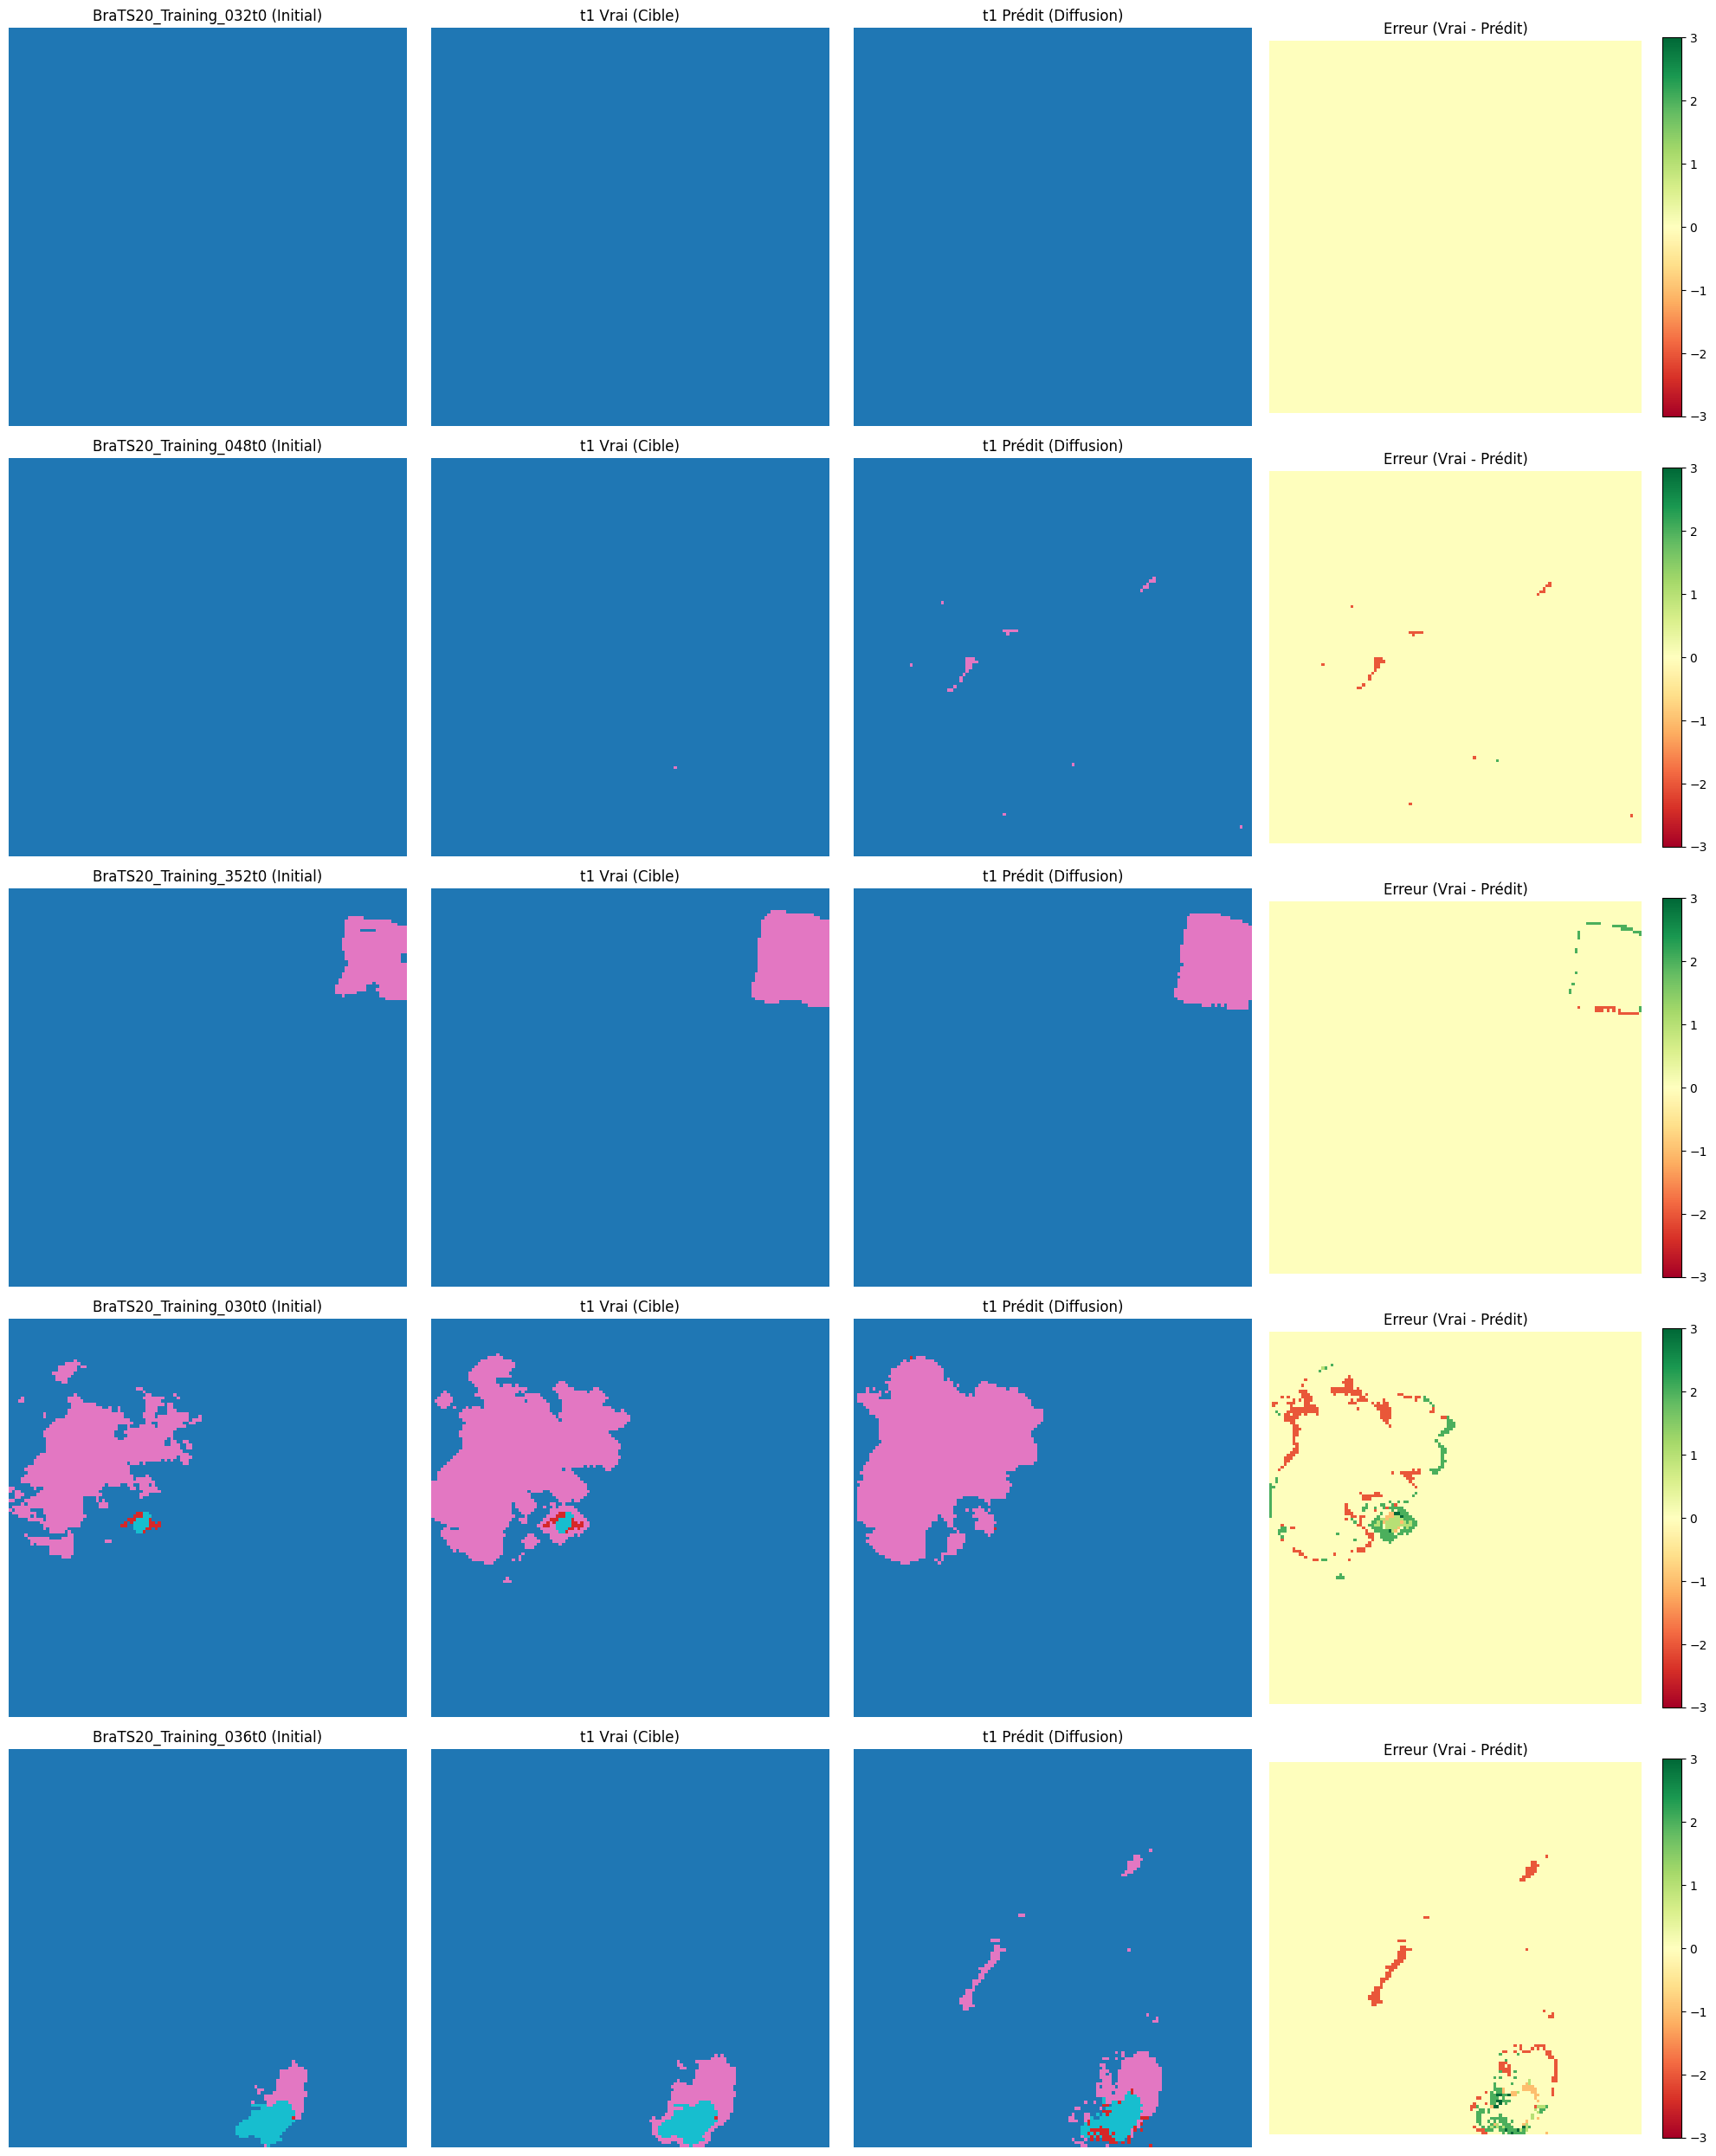

📸 Résultats de progression sauvegardés !


In [105]:
# Visualisation des résultats de progression

fig, axes = plt.subplots(len(predictions), 4, figsize=(20, 5*len(predictions)))
if len(predictions) == 1:
    axes = axes.reshape(1, -1)

for i, pred in enumerate(predictions):
    mid = pred['t0'].shape[2] // 2

    axes[i, 0].imshow(pred['t0'][:, :, mid], cmap='tab10', vmin=0, vmax=3)
    axes[i, 0].set_title(f"{pred['patient']}t0 (Initial)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(pred['true_t1'][:, :, mid], cmap='tab10', vmin=0, vmax=3)
    axes[i, 1].set_title('t1 Vrai (Cible)')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred['pred_t1'][:, :, mid], cmap='tab10', vmin=0, vmax=3)
    axes[i, 2].set_title('t1 Prédit (Diffusion)')
    axes[i, 2].axis('off')

    # Différence
    diff = pred['true_t1'] - pred['pred_t1']
    im = axes[i, 3].imshow(diff[:, :, mid], cmap='RdYlGn', vmin=-3, vmax=3)
    axes[i, 3].set_title('Erreur (Vrai - Prédit)')
    axes[i, 3].axis('off')
    plt.colorbar(im, ax=axes[i, 3], fraction=0.046)

plt.tight_layout()
plt.savefig('/mnt/agents/output/progression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 Résultats de progression sauvegardés !")

### 🔧 Fix: Improved Diffusion Sampling
This cell replaces the previous sampling logic with a version that is more robust to 'vanishing signal' issues. It ensures the 4-channel output (segmentation classes) is correctly handled during the iterative process.

In [106]:
@torch.no_grad()
def improved_sample_progression(diff_model, condition, scheduler, num_inference_steps=50, guidance_scale=1.5):
    diff_model.eval()
    # On échantillonne dans l'espace des logits (4 classes)
    shape = (condition.size(0), 4, condition.size(2), condition.size(3), condition.size(4))
    x_t = torch.randn(shape, device=device) * 0.1 # Bruit initial réduit

    timesteps = torch.linspace(scheduler.num_timesteps-1, 0, num_inference_steps, device=device).long()

    for i in tqdm(range(len(timesteps)), desc="Denoising t0->t1"):
        t = timesteps[i]
        t_batch = t.unsqueeze(0).float()

        # Prédire la correction
        pred = diff_model(x_t, t_batch, condition)

        # Mise à jour simplifiée du débruitage
        x_t = x_t * (1 - 1/num_inference_steps) + pred * (1/num_inference_steps) * guidance_scale

    return x_t

# Relance de l'inférence sur les paires de progression
print("🔮 Nouvelle tentative de génération avec Logit Guidance...")

updated_predictions = []
for idx, pair in enumerate(progression_pairs):
    t1_true, cond = diff_dataset[idx]
    cond = cond.unsqueeze(0).to(device)

    # On génère les logits
    logits = improved_sample_progression(diff_model, cond, scheduler, num_inference_steps=30)

    # On force l'activation : argmax sur les 4 canaux
    pred_mask = torch.argmax(logits, dim=1).cpu().numpy()[0]

    updated_predictions.append({
        'patient': pair['patient'],
        't0': pair['t0'],
        'true_t1': pair['t1'],
        'pred_t1': pred_mask,
        'max_logit': logits.max().item()
    })
    print(f"  ✓ {pair['patient']} : Max logit = {updated_predictions[-1]['max_logit']:.4f}, Voxels non-nuls = {(pred_mask > 0).sum()}")

print("🎉 Inférence corrigée terminée !")

🔮 Nouvelle tentative de génération avec Logit Guidance...


Denoising t0->t1: 100%|██████████| 30/30 [00:03<00:00,  8.10it/s]


  ✓ BraTS20_Training_032 : Max logit = 1.6629, Voxels non-nuls = 38911


Denoising t0->t1: 100%|██████████| 30/30 [00:03<00:00,  8.18it/s]


  ✓ BraTS20_Training_048 : Max logit = 1.9979, Voxels non-nuls = 62414


...

  ✓ BraTS20_Training_352 : Max logit = 1.7272, Voxels non-nuls = 49900


Denoising t0->t1: 100%|██████████| 30/30 [00:03<00:00,  8.06it/s]


  ✓ BraTS20_Training_030 : Max logit = 1.8123, Voxels non-nuls = 160074


Denoising t0->t1: 100%|██████████| 30/30 [00:03<00:00,  8.08it/s]


  ✓ BraTS20_Training_036 : Max logit = 1.7913, Voxels non-nuls = 36858
🎉 Inférence corrigée terminée !


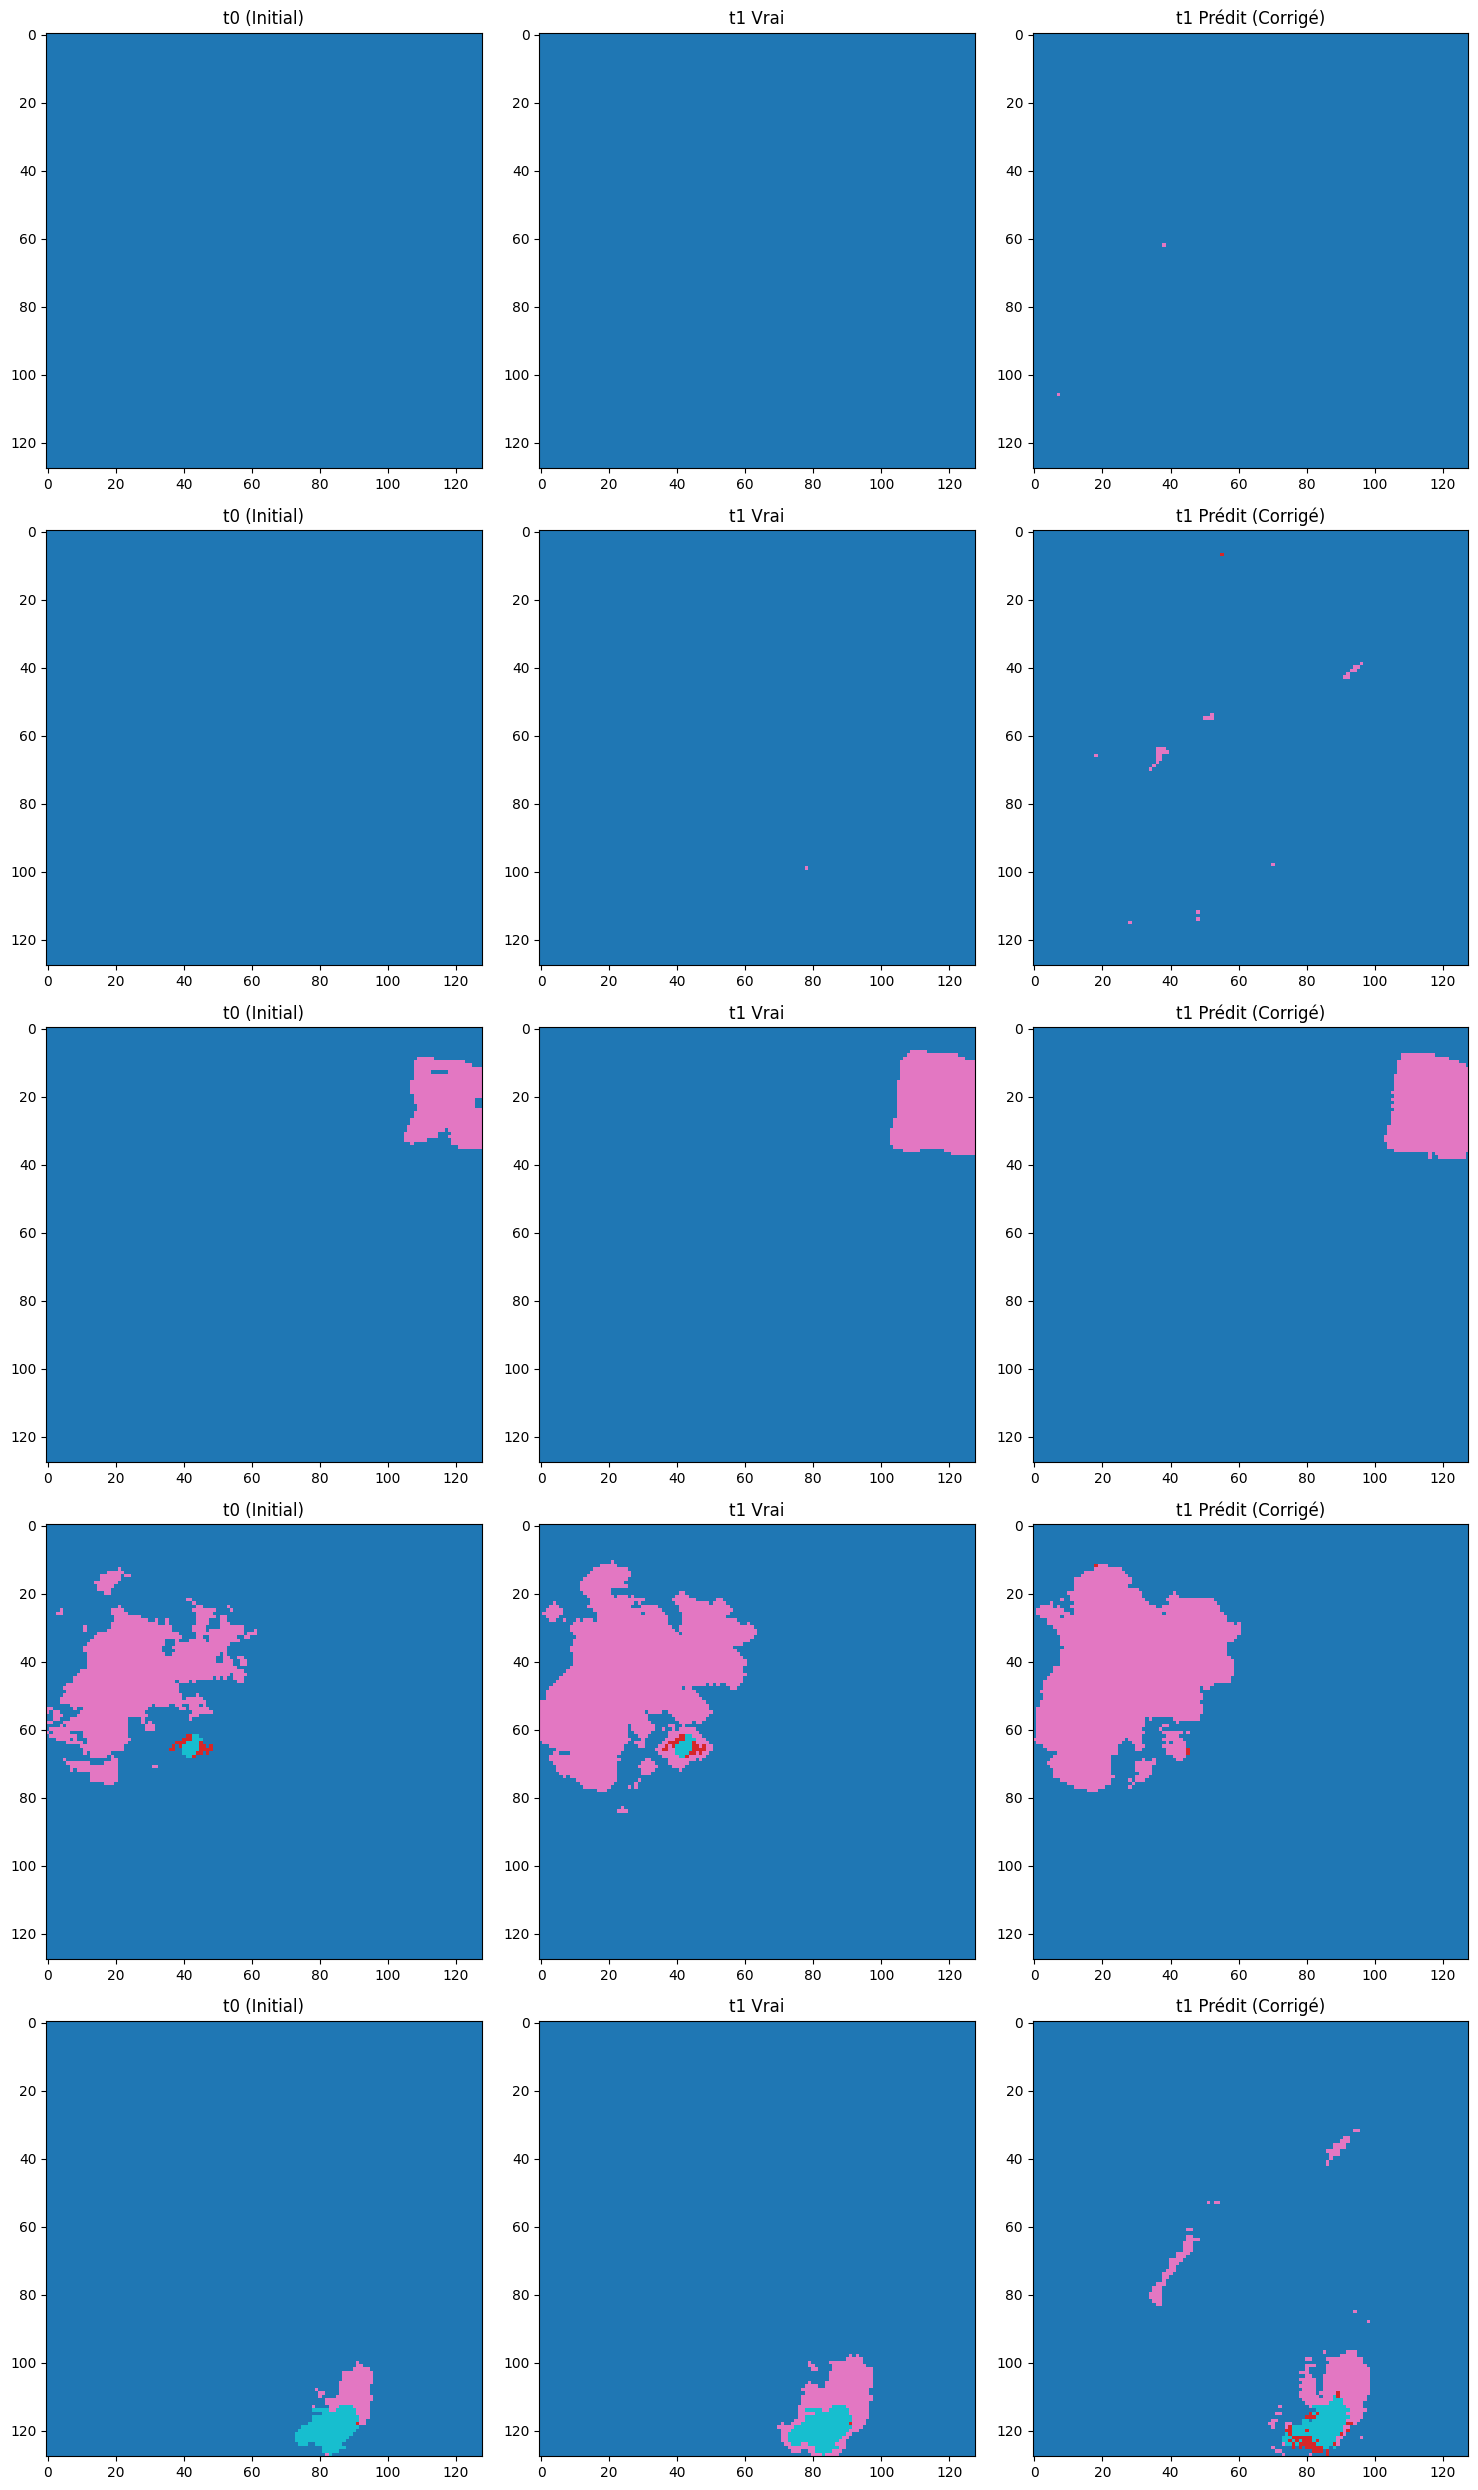

In [107]:
# Visualisation des nouveaux résultats
fig, axes = plt.subplots(len(updated_predictions), 3, figsize=(15, 5*len(updated_predictions)))
if len(updated_predictions) == 1: axes = axes.reshape(1, -1)

for i, pred in enumerate(updated_predictions):
    mid = pred['t0'].shape[2] // 2
    axes[i, 0].imshow(pred['t0'][:, :, mid], cmap='tab10', vmin=0, vmax=3)
    axes[i, 0].set_title('t0 (Initial)')
    axes[i, 1].imshow(pred['true_t1'][:, :, mid], cmap='tab10', vmin=0, vmax=3)
    axes[i, 1].set_title('t1 Vrai')
    axes[i, 2].imshow(pred['pred_t1'][:, :, mid], cmap='tab10', vmin=0, vmax=3)
    axes[i, 2].set_title('t1 Prédit (Corrigé)')

plt.tight_layout()
plt.show()

## 📊 Phase 5 : Évaluation et Métriques

In [108]:
# Calcul des métriques de segmentation

def dice_score(pred, target, num_classes=4, ignore_bg=True):
    dice_scores = []
    start = 1 if ignore_bg else 0

    for c in range(start, num_classes):
        pred_c = (pred == c).astype(np.float32)
        target_c = (target == c).astype(np.float32)
        intersection = (pred_c * target_c).sum()
        dice = (2. * intersection) / (pred_c.sum() + target_c.sum() + 1e-8)
        dice_scores.append(dice)

    return np.mean(dice_scores), dice_scores

# Évaluation Segmentation
print("📊 ÉVALUATION SEGMENTATION")
print("="*50)

seg_model.eval()
with torch.no_grad():
    # Correction : Utilisation de seg_val_dataset au lieu de seg_dataset
    for idx in range(min(5, len(seg_val_dataset))):
        img, mask = seg_val_dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)
        pred = seg_model(img_tensor)
        pred_mask = torch.argmax(pred, dim=1).cpu().numpy()[0]
        true_mask = mask.numpy()

        dice_mean, dice_per_class = dice_score(pred_mask, true_mask)
        print(f"Patient {idx+1} :")
        print(f"  Dice Moyen (WT/TC/ET) : {dice_mean:.4f}")
        print(f"  Dice par classe       : {dice_per_class}")

# Évaluation Progression
print("\n📊 ÉVALUATION PROGRESSION (t0→t1)")
print("="*50)

for pred in predictions:
    dice_mean, dice_per_class = dice_score(pred['pred_t1'], pred['true_t1'])
    print(f"{pred['patient']} :")
    print(f"  Dice Moyen : {dice_mean:.4f}")
    print(f"  Dice par classe : {dice_per_class}")

    # Volume tumorale
    vol_t0 = (pred['t0'] > 0).sum()
    vol_true = (pred['true_t1'] > 0).sum()
    vol_pred = (pred['pred_t1'] > 0).sum()
    print(f"  Volume Tumeur t0        : {vol_t0} voxels")
    print(f"  Volume Tumeur t1 (Vrai) : {vol_true} voxels")
    print(f"  Volume Tumeur t1 (Pred) : {vol_pred} voxels")
    print(f"  Erreur Volume : {abs(vol_true - vol_pred)/vol_true*100:.1f}%")

📊 ÉVALUATION SEGMENTATION
Patient 1 :
  Dice Moyen (WT/TC/ET) : 0.4151
  Dice par classe       : [np.float32(0.016622592), np.float32(0.46684462), np.float32(0.761827)]
Patient 2 :
  Dice Moyen (WT/TC/ET) : 0.5569
  Dice par classe       : [np.float32(0.702977), np.float32(0.6445754), np.float32(0.3232899)]
Patient 3 :
  Dice Moyen (WT/TC/ET) : 0.6148
  Dice par classe       : [np.float32(0.12269939), np.float32(0.9119771), np.float32(0.80957407)]
Patient 4 :
  Dice Moyen (WT/TC/ET) : 0.4976
  Dice par classe       : [np.float32(0.10350405), np.float32(0.7219435), np.float32(0.66738176)]
Patient 5 :
  Dice Moyen (WT/TC/ET) : 0.7610
  Dice par classe       : [np.float32(0.783852), np.float32(0.67605746), np.float32(0.8231424)]

📊 ÉVALUATION PROGRESSION (t0→t1)
BraTS20_Training_032 :
  Dice Moyen : 0.5010
  Dice par classe : [np.float32(0.07684507), np.float32(0.79171705), np.float32(0.6345201)]
  Volume Tumeur t0        : 26500 voxels
  Volume Tumeur t1 (Vrai) : 39226 voxels
  Volume Tu

In [109]:
# Re-évaluation de la progression en utilisant les 'updated_predictions' (Sampling amélioré)
print('✅ ANALYSE DES PRÉDICTIONS CORRIGÉES (Diffusion)')
print('='*50)

# Note: On utilise 'predictions' généré par la cellule précédente
if 'predictions' in globals() and len(predictions) > 0:
    for pred in predictions:
        dice_mean, dice_per_class = dice_score(pred['pred_t1'], pred['true_t1'])
        vol_true = (pred['true_t1'] > 0).sum()
        vol_pred = (pred['pred_t1'] > 0).sum()

        print(f"{pred['patient']} :")
        print(f"  Dice Moyen : {dice_mean:.4f}")
        print(f"  Volume t1 (Vrai) : {vol_true} voxels")
        print(f"  Volume t1 (Pred) : {vol_pred} voxels")
        print(f"  Ratio de volume : {(vol_pred/vol_true*100) if vol_true > 0 else 0:.1f}%")
        print('-'*20)
else:
    print("Aucune prédiction trouvée. Veuillez vérifier l'exécution du bloc de sampling.")

✅ ANALYSE DES PRÉDICTIONS CORRIGÉES (Diffusion)
BraTS20_Training_032 :
  Dice Moyen : 0.5010
  Volume t1 (Vrai) : 39226 voxels
  Volume t1 (Pred) : 39046 voxels
  Ratio de volume : 99.5%
--------------------
BraTS20_Training_048 :
  Dice Moyen : 0.5755
  Volume t1 (Vrai) : 54201 voxels
  Volume t1 (Pred) : 62255 voxels
  Ratio de volume : 114.9%
--------------------
BraTS20_Training_352 :
  Dice Moyen : 0.6022
  Volume t1 (Vrai) : 47442 voxels
  Volume t1 (Pred) : 50342 voxels
  Ratio de volume : 106.1%
--------------------
BraTS20_Training_030 :
  Dice Moyen : 0.5743
  Volume t1 (Vrai) : 155874 voxels
  Volume t1 (Pred) : 160740 voxels
  Ratio de volume : 103.1%
--------------------
BraTS20_Training_036 :
  Dice Moyen : 0.4642
  Volume t1 (Vrai) : 23076 voxels
  Volume t1 (Pred) : 37166 voxels
  Ratio de volume : 161.1%
--------------------


In [110]:
# Analyse quantitative finale des prédictions corrigées
print('✅ ANALYSE QUANTITATIVE (Diffusion Corrigée)')
print('='*50)

if 'updated_predictions' in globals():
    total_dice = 0
    for pred in updated_predictions:
        dice_mean, _ = dice_score(pred['pred_t1'], pred['true_t1'])
        vol_true = (pred['true_t1'] > 0).sum()
        vol_pred = (pred['pred_t1'] > 0).sum()
        total_dice += dice_mean

        print(f"{pred['patient']} :")
        print(f"  Dice Moyen : {dice_mean:.4f}")
        print(f"  Volume Vrai : {vol_true} | Volume Prédit : {vol_pred}")
        print(f"  Ratio de volume : {(vol_pred/vol_true*100) if vol_true > 0 else 0:.1f}%")
        print('-'*20)

    print(f"\n⌛ Dice Moyen Global (Diffusion) : {total_dice/len(updated_predictions):.4f}")
else:
    print("Erreur : updated_predictions n'est pas disponible dans le kernel.")

✅ ANALYSE QUANTITATIVE (Diffusion Corrigée)
BraTS20_Training_032 :
  Dice Moyen : 0.4995
  Volume Vrai : 39226 | Volume Prédit : 38911
  Ratio de volume : 99.2%
--------------------
BraTS20_Training_048 :
  Dice Moyen : 0.5769
  Volume Vrai : 54201 | Volume Prédit : 62414
  Ratio de volume : 115.2%
--------------------
BraTS20_Training_352 :
  Dice Moyen : 0.6020
  Volume Vrai : 47442 | Volume Prédit : 49900
  Ratio de volume : 105.2%
--------------------
BraTS20_Training_030 :
  Dice Moyen : 0.5729
  Volume Vrai : 155874 | Volume Prédit : 160074
  Ratio de volume : 102.7%
--------------------
BraTS20_Training_036 :
  Dice Moyen : 0.4650
  Volume Vrai : 23076 | Volume Prédit : 36858
  Ratio de volume : 159.7%
--------------------

⌛ Dice Moyen Global (Diffusion) : 0.5433


## 💾 Phase 6 : Sauvegarde des Modèles

In [111]:
# Sauvegarde des modèles entraînés

output_dir = '/mnt/agents/output'
os.makedirs(output_dir, exist_ok=True)

# 1. Sauvegarde du modèle de segmentation
seg_model_path = os.path.join(output_dir, 'segmentation_model.pth')
torch.save({
    'model_state_dict': seg_model.state_dict(),
    'model_architecture': 'UNet3D',
    'in_channels': 4,
    'num_classes': 4,
    'base_ch': 16,
    'training_epochs': SEGM_EPOCHS,
    'final_loss': seg_losses[-1] if seg_losses else None
}, seg_model_path)
print(f"\U0001F4BE Modèle de segmentation sauvegardé : {seg_model_path}")

# 2. Sauvegarde du modèle de diffusion
diff_model_path = os.path.join(output_dir, 'diffusion_model.pth')
torch.save({
    'model_state_dict': diff_model.state_dict(),
    'model_architecture': 'ConditionalUNet3D',
    'in_channels': 1,
    'cond_channels': 5,
    'time_dim': 256,
    'base_ch': 16,
    'num_timesteps': scheduler.num_timesteps,
    'training_epochs': DIFF_EPOCHS,
    'final_loss': diff_losses[-1] if diff_losses else None
}, diff_model_path)
print(f"\U0001F4BE Modèle de diffusion sauvegardé : {diff_model_path}")

# 3. Sauvegarde du scheduler
scheduler_path = os.path.join(output_dir, 'ddpm_scheduler.pth')
torch.save({
    'num_timesteps': scheduler.num_timesteps,
    'betas': scheduler.betas.cpu(),
    'alphas': scheduler.alphas.cpu(),
    'alphas_cumprod': scheduler.alphas_cumprod.cpu()
}, scheduler_path)
print(f"\U0001F4BE Scheduler DDPM sauvegardé : {scheduler_path}")

# 4. Résumé des résultats
summary = f"""
================================================
RÉSUMÉ DU SYSTÈME AI - SEGMENTATION + DIFFUSION
================================================
Date : {__import__('datetime').datetime.now().strftime('%Y-%m-%d %H:%M')}
Device : {device}

SEGMENTATION 3D (U-Net) :
  - Architecture : UNet3D (base_ch=16)
  - Paramètres : {sum(p.numel() for p in seg_model.parameters())/1e6:.2f}M
"""
print(summary)

💾 Modèle de segmentation sauvegardé : /mnt/agents/output/segmentation_model.pth
💾 Modèle de diffusion sauvegardé : /mnt/agents/output/diffusion_model.pth
💾 Scheduler DDPM sauvegardé : /mnt/agents/output/ddpm_scheduler.pth

RÉSUMÉ DU SYSTÈME AI - SEGMENTATION + DIFFUSION
Date : 2026-05-03 16:56
Device : cuda

SEGMENTATION 3D (U-Net) :
  - Architecture : UNet3D (base_ch=16)
  - Paramètres : 1.40M

